# Student Marks Prediction — Machine Learning Project

**B.Tech CSE (AI & ML) Project**



# Step 1: Project Configuration



- **Target:** `math score`
- **Features:** all other columns


In [22]:
# Step 1: Project Configuration

import os

DATA_PATH =r"C:\Users\user\Downloads\archive (1)\exams.csv"

TARGET_COLUMN = "math score"


FEATURE_COLUMNS = None

TASK = "regression"

TEST_SIZE = 0.20
RANDOM_STATE = 51

MODEL_DIR = "models"
MODEL_PATH = os.path.join(MODEL_DIR, "student_marks_predictor.joblib")

os.makedirs(MODEL_DIR, exist_ok=True)

print("Data path:", DATA_PATH)
print("Target:", TARGET_COLUMN)
print("Feature configuration:", "all columns except target" if FEATURE_COLUMNS is None else FEATURE_COLUMNS)

Data path: C:\Users\user\Downloads\archive (1)\exams.csv
Target: math score
Feature configuration: all columns except target


# Step 2: Import Libraries

The notebook uses pandas/numpy for data handling, matplotlib/seaborn for EDA, scikit-learn for preprocessing and models, and joblib for saving/loading the complete trained pipeline.

In [23]:
# Step 2: Import Libraries

import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


# Step 3: Load the Kaggle Dataset

Place your CSV inside the `data` folder and update `DATA_PATH` if the filename is different. No data is generated by the notebook.

In [24]:
# Step 3: Load Dataset

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}\n"
        "Place your Kaggle CSV in the data folder and update DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (1000, 8)


# Step 4: Basic Dataset Inspection

In [25]:
# Step 4: Basic Dataset Inspection

print("First 5 records:")
display(df.head())

print("\nLast 5 records:")
display(df.tail())

print("\nDataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nDataset information:")
df.info()

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

First 5 records:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group A,high school,standard,completed,67,67,63
1,female,group D,some high school,free/reduced,none,40,59,55
2,male,group E,some college,free/reduced,none,59,60,50
3,male,group B,high school,standard,none,77,78,68
4,male,group E,associate's degree,standard,completed,78,73,68



Last 5 records:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,male,group C,high school,standard,none,73,70,65
996,male,group D,associate's degree,free/reduced,completed,85,91,92
997,female,group C,some high school,free/reduced,none,32,35,41
998,female,group C,some college,standard,none,73,74,82
999,male,group A,some college,standard,completed,65,60,62



Dataset shape: (1000, 8)

Column names:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

Data types:


,dtype
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB

Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,1000,2,male,517,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race/ethnicity,1000,5,group C,323,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parental level of education,1000,6,some college,222,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lunch,1000,2,standard,652,NaN,NaN,NaN,NaN,NaN,NaN,NaN
test preparation course,1000,2,none,665,NaN,NaN,NaN,NaN,NaN,NaN,NaN
math score,1000.0,NaN,NaN,NaN,66.396,15.402871,13.0,56.0,66.5,77.0,100.0
reading score,1000.0,NaN,NaN,NaN,69.002,14.737272,27.0,60.0,70.0,79.0,100.0
writing score,1000.0,NaN,NaN,NaN,67.738,15.600985,23.0,58.0,68.0,79.0,100.0


# Step 5: Validate Target and Feature Configuration

This prevents silent assumptions. If a column is missing, the notebook stops and shows the available columns.

In [26]:
# Step 5: Validate Configuration

if TARGET_COLUMN not in df.columns:
    raise ValueError(
        f"Target column '{TARGET_COLUMN}' was not found.\n"
        f"Available columns: {df.columns.tolist()}"
    )

if FEATURE_COLUMNS is None:
    selected_features = [c for c in df.columns if c != TARGET_COLUMN]
else:
    selected_features = FEATURE_COLUMNS.copy()

missing_features = [c for c in selected_features if c not in df.columns]
if missing_features:
    raise ValueError(
        f"Configured feature columns were not found: {missing_features}\n"
        f"Available columns: {df.columns.tolist()}"
    )

if TARGET_COLUMN in selected_features:
    raise ValueError("The target column must not also be used as a feature.")

print("Selected features:", selected_features)
print("Target:", TARGET_COLUMN)
print("Task:", TASK)

Selected features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'reading score', 'writing score']
Target: math score
Task: regression


# Step 6: Missing-Value and Duplicate Analysis

Duplicates are reported and exact duplicate rows are removed. Missing values are **not** manually filled here; they are handled later inside the training pipeline so that imputation statistics are learned only from the training set.

In [27]:
# Step 6: Missing Values and Duplicates

print("Missing values:")
display(df.isnull().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nMissing-value percentage:")
display((df.isnull().mean() * 100).sort_values(ascending=False).to_frame("missing_percent"))

duplicate_count = df.duplicated().sum()
print("\nDuplicate rows:", duplicate_count)

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing exact duplicates:", df.shape)

Missing values:


,missing_count
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0



Missing-value percentage:


,missing_percent
gender,0.0
race/ethnicity,0.0
parental level of education,0.0
lunch,0.0
test preparation course,0.0
math score,0.0
reading score,0.0
writing score,0.0



Duplicate rows: 1
Shape after removing exact duplicates: (999, 8)


# Step 7: Target Variable Distribution

For this dataset the target is numeric, so the task is regression and a histogram is appropriate.

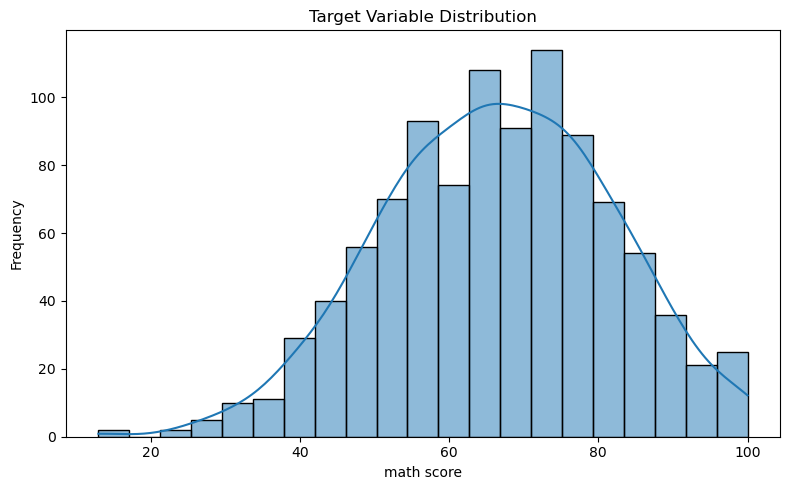

In [28]:
# Step 7: Target Distribution

plt.figure(figsize=(8, 5))
sns.histplot(df[TARGET_COLUMN].dropna(), kde=True)
plt.xlabel(TARGET_COLUMN)
plt.ylabel("Frequency")
plt.title("Target Variable Distribution")
plt.tight_layout()
plt.show()

# Step 8: Numerical Feature Histograms

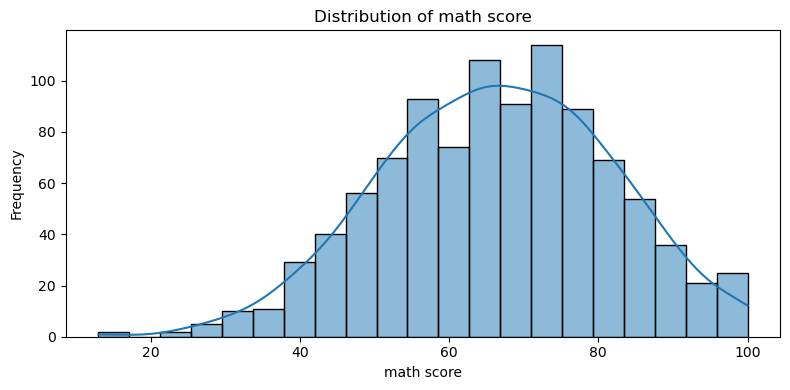

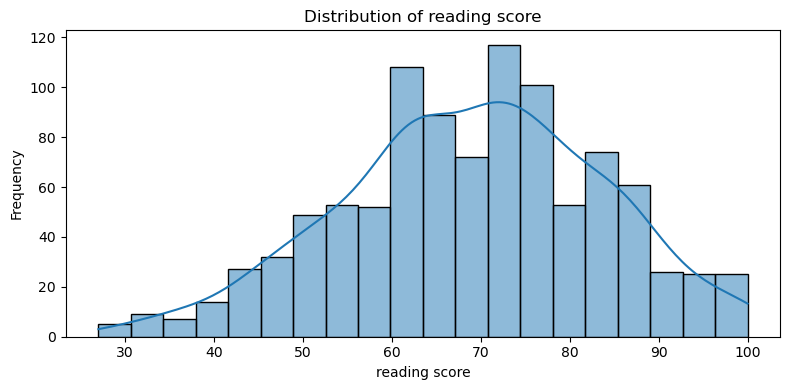

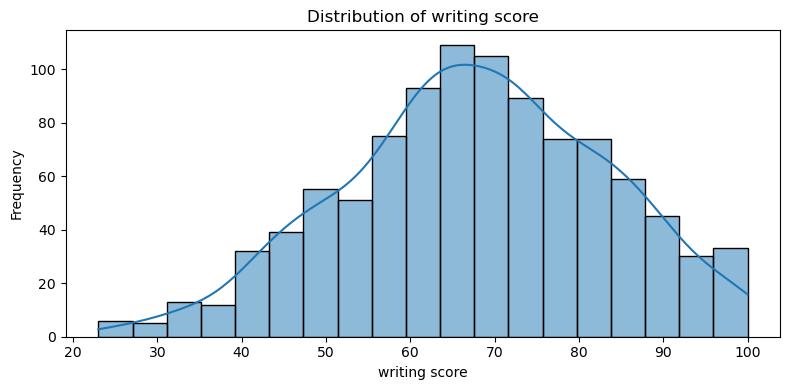

In [29]:
# Step 8: Numerical Feature Distributions

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[column].dropna(), kde=True)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# Step 9: Box Plots

Box plots help identify spread and possible outliers without automatically deleting valid student-score observations.

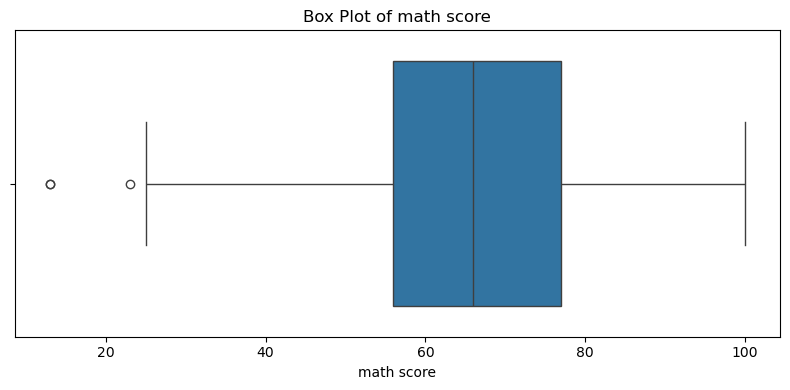

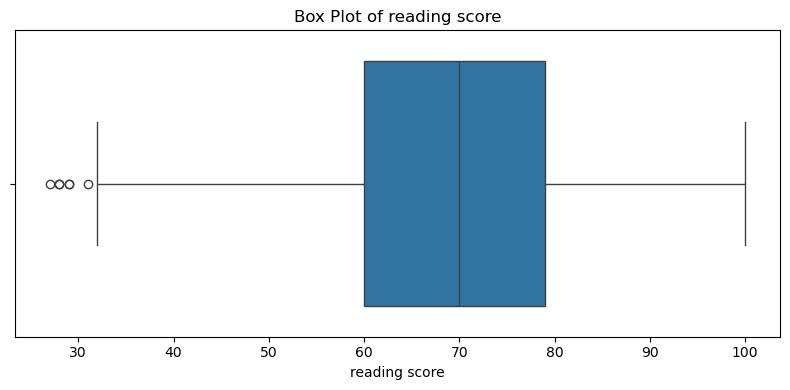

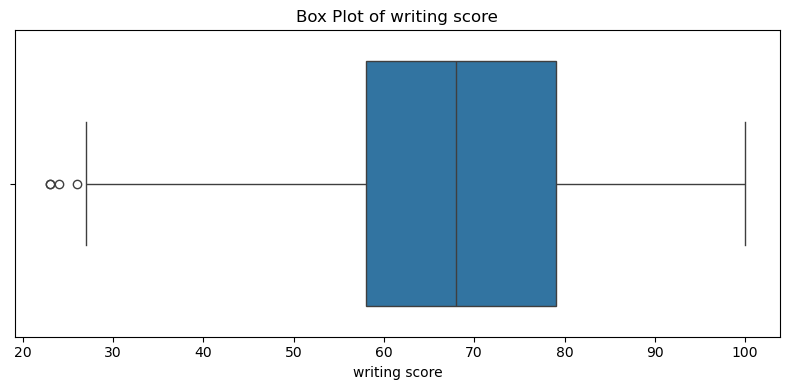

In [30]:
# Step 9: Box Plots

for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[column])
    plt.title(f"Box Plot of {column}")
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()

# Step 10: Categorical Count Plots

Only reasonably small categorical columns are plotted to keep the EDA meaningful.

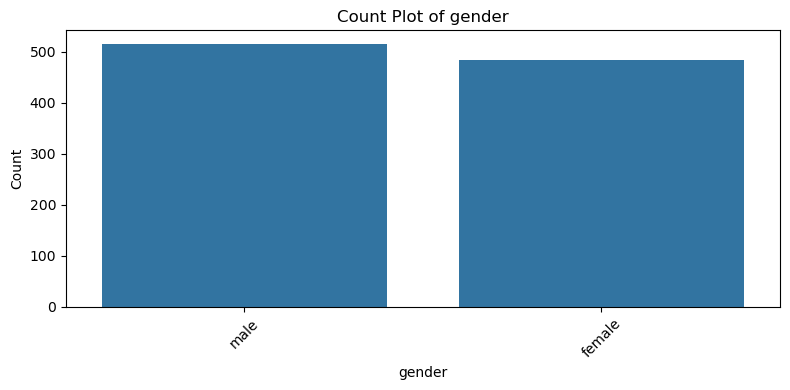

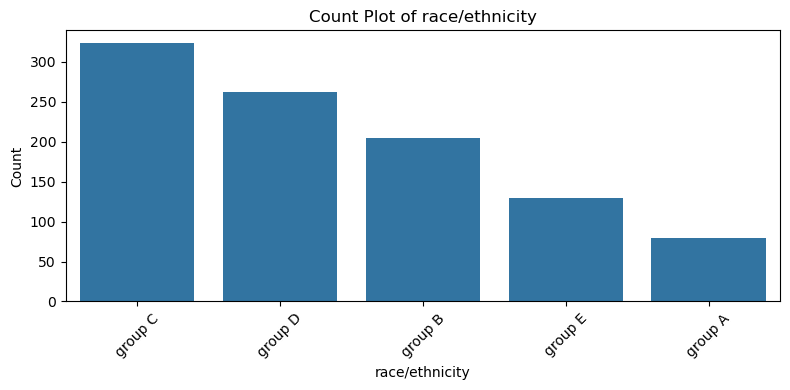

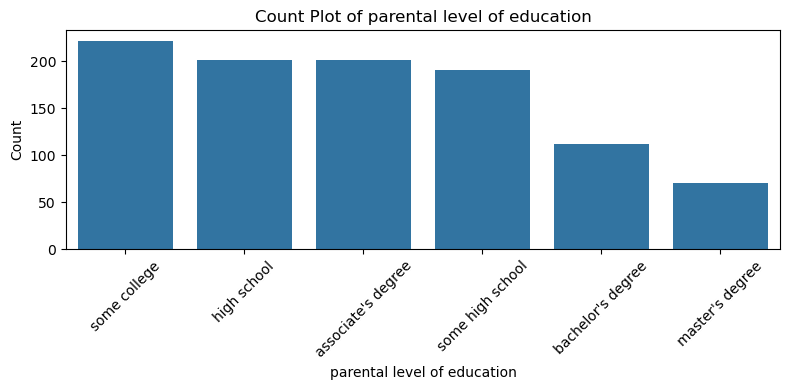

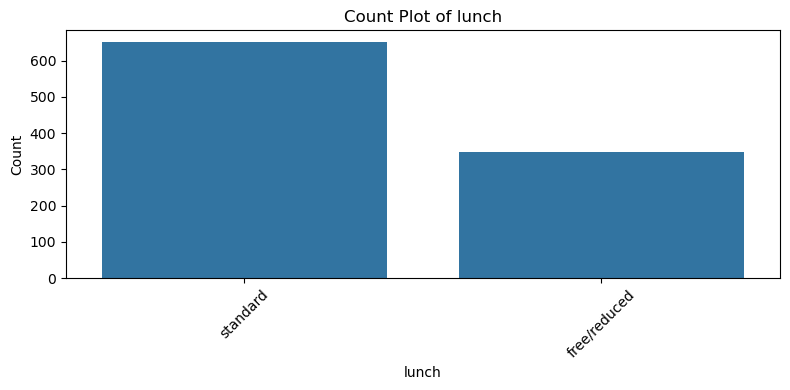

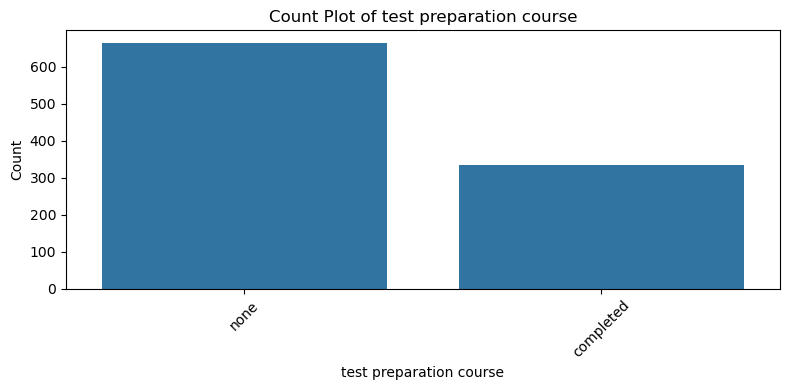

In [31]:
# Step 10: Categorical Count Plots

categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

for column in categorical_columns:
    if df[column].nunique(dropna=True) <= 20:
        plt.figure(figsize=(8, 4))
        order = df[column].value_counts(dropna=False).index
        sns.countplot(data=df, x=column, order=order)
        plt.title(f"Count Plot of {column}")
        plt.xlabel(column)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# Step 11: Numerical Features vs Target

Scatter plots are useful for numeric predictors because they show the relationship with the marks target.

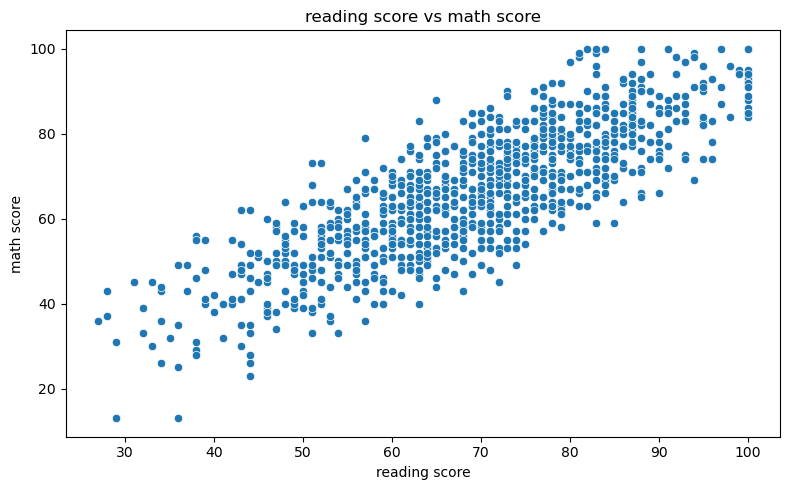

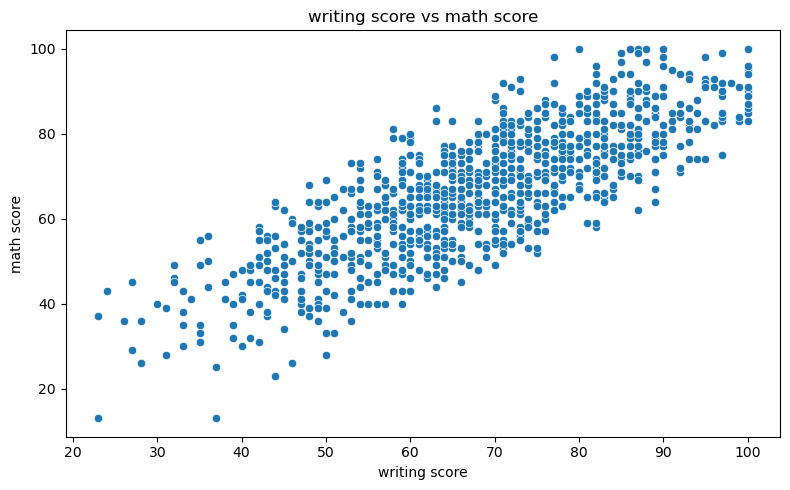

In [32]:
# Step 11: Scatter Plots

numeric_features_for_scatter = [
    c for c in selected_features if c in numeric_columns
]

for feature in numeric_features_for_scatter:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=feature, y=TARGET_COLUMN)
    plt.xlabel(feature)
    plt.ylabel(TARGET_COLUMN)
    plt.title(f"{feature} vs {TARGET_COLUMN}")
    plt.tight_layout()
    plt.show()

# Step 12: Correlation Heatmap

The heatmap is calculated only for numeric columns. It is descriptive EDA and is not used to fit the model.

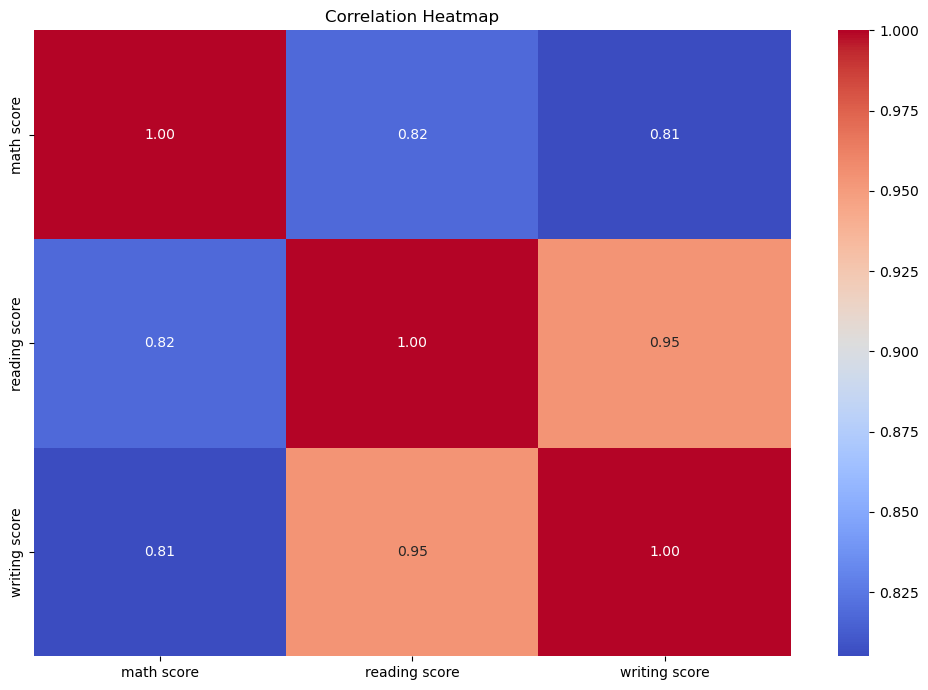

In [12]:
# Step 12: Correlation Heatmap

corr_columns = df.select_dtypes(include=np.number).columns.tolist()

if len(corr_columns) >= 2:
    plt.figure(figsize=(10, 7))
    sns.heatmap(df[corr_columns].corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()
else:
    print("At least two numerical columns are required.")

# Step 13: Prepare X and y

In [33]:
# Step 13: Create Feature Matrix X and Target y

X = df[selected_features].copy()
y = df[TARGET_COLUMN].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(X.dtypes.to_frame("feature_dtype"))
print("Target dtype:", y.dtype)

X shape: (999, 7)
y shape: (999,)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,male,group A,high school,standard,completed,67,63
1,female,group D,some high school,free/reduced,none,59,55
2,male,group E,some college,free/reduced,none,60,50
3,male,group B,high school,standard,none,78,68
4,male,group E,associate's degree,standard,completed,73,68


,feature_dtype
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
reading score,int64
writing score,int64


Target dtype: int64


# Step 14: Train-Test Split

The test set is kept separate until final evaluation. This is important for avoiding overly optimistic performance estimates.

In [34]:
# Step 14: Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (799, 7)
X_test : (200, 7)
y_train: (799,)
y_test : (200,)


# Step 15: Leakage-Safe Preprocessing

Numeric features use median imputation and scaling. Categorical features use most-frequent imputation and one-hot encoding. All transformations are inside a scikit-learn `Pipeline`, so the same fitted preprocessing is automatically applied to new predictions.

In [35]:
# Step 15: Build Preprocessing Pipeline

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
], remainder="drop")

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['reading score', 'writing score']
Categorical features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


# Step 16: Select Regression Models

The target `math score` is numeric, so this is a **regression** problem.

- **Linear Regression:** a strong interpretable baseline.
- **Decision Tree Regressor:** captures nonlinear relationships.
- **Random Forest Regressor:** combines many trees and can model nonlinear interactions.
- **Gradient Boosting Regressor:** builds trees sequentially to reduce prediction error.

These models provide a useful comparison without adding unnecessary algorithms.

In [36]:
# Step 16: Define Regression Models

models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree Regressor": DecisionTreeRegressor(
        random_state=RANDOM_STATE,
        max_depth=5
    ),

    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting Regressor": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),
}

print("Models selected:")
for name in models:
    print("-", name)

Models selected:
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor


# Step 17: Train Models and Create Actual Model-Comparison Table

The metrics below are calculated from the uploaded dataset when this notebook is executed. No performance values are hard-coded.

In [37]:
# Step 17: Train and Compare Models

trained_pipelines = {}
results = []

for model_name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)
    trained_pipelines[model_name] = pipeline

    mse = mean_squared_error(y_test, predictions)

    results.append({
        "Model": model_name,
        "MAE": mean_absolute_error(y_test, predictions),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_test, predictions),
    })

results_df = (
    pd.DataFrame(results)
    .sort_values("RMSE", ascending=True)
    .reset_index(drop=True)
)

display(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_pipelines[best_model_name]

print("Selected model based on lowest test RMSE:", best_model_name)

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,4.805656,35.526934,5.960447,0.850123
1,Gradient Boosting Regressor,5.127263,39.962031,6.321553,0.831412
2,Random Forest Regressor,5.373925,45.618425,6.754141,0.807550
3,Decision Tree Regressor,5.839878,54.247186,7.365269,0.771148


Selected model based on lowest test RMSE: Linear Regression


# Step 18: Detailed Evaluation of the Selected Model

In [38]:
# Step 18: Evaluate Selected Model

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Selected Model: {best_model_name}")
print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

Selected Model: Linear Regression
MAE : 4.8057
MSE : 35.5269
RMSE: 5.9604
R²  : 0.8501


# Step 19: Actual vs Predicted Graph

Points closer to the diagonal line indicate predictions closer to the actual marks.

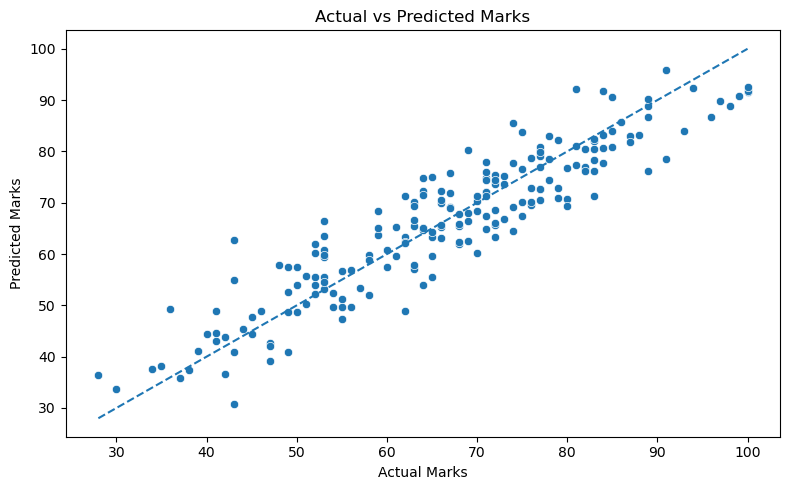

In [39]:
# Step 19: Actual vs Predicted

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred)

low = min(y_test.min(), y_pred.min())
high = max(y_test.max(), y_pred.max())

plt.plot([low, high], [low, high], linestyle="--")
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")
plt.tight_layout()
plt.show()

# Step 20: Actual vs Predicted Table

In [40]:
# Step 20: Actual vs Predicted Table

comparison = X_test.copy()
comparison["Actual"] = y_test.values
comparison["Predicted"] = y_pred
comparison["Absolute Error"] = np.abs(
    comparison["Actual"] - comparison["Predicted"]
)

display(comparison.reset_index(drop=True).head(20))

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score,Actual,Predicted,Absolute Error
0,male,group A,master's degree,standard,none,83,78,85,84.022245,0.977755
1,male,group D,some college,standard,none,68,65,83,71.247787,11.752213
2,female,group D,bachelor's degree,standard,none,81,80,71,71.998952,0.998952
3,female,group D,bachelor's degree,free/reduced,none,87,90,82,76.599277,5.400723
4,male,group B,master's degree,standard,completed,71,68,80,70.708550,9.291450
5,male,group E,high school,free/reduced,none,86,73,93,84.068386,8.931614
6,male,group C,bachelor's degree,standard,none,84,88,100,91.595664,8.404336
7,female,group C,master's degree,standard,completed,79,89,71,74.774014,3.774014
8,female,group E,some college,free/reduced,none,88,86,82,80.437674,1.562326
9,male,group B,associate's degree,free/reduced,none,63,57,68,61.891564,6.108436


# Step 21: Save the Complete Model Package

The fitted preprocessing pipeline and model are saved together. The package also stores the feature names and a schema used by the Streamlit GUI.

In [41]:
# Step 21: Save Model + Preprocessing + Feature Schema

feature_schema = {}

for column in selected_features:
    series = X_train[column]

    if pd.api.types.is_numeric_dtype(series):
        non_null = pd.to_numeric(series, errors="coerce").dropna()

        feature_schema[column] = {
            "type": "numeric",
            "min": float(non_null.min()) if len(non_null) else 0.0,
            "max": float(non_null.max()) if len(non_null) else 100.0,
            "median": float(non_null.median()) if len(non_null) else 0.0,
        }

    else:
        categories = series.dropna().astype(str).unique().tolist()

        feature_schema[column] = {
            "type": "categorical",
            "categories": categories,
        }

model_package = {
    "pipeline": best_model,
    "feature_columns": selected_features,
    "target_column": TARGET_COLUMN,
    "task_type": TASK,
    "model_name": best_model_name,
    "feature_schema": feature_schema,
}

joblib.dump(model_package, MODEL_PATH)

print("Model package saved successfully.")
print("Saved path:", MODEL_PATH)

Model package saved successfully.
Saved path: models\student_marks_predictor.joblib


# Step 22: Load the Saved Model

Loading the saved package demonstrates that prediction does not require retraining.

In [42]:
# Step 22: Load Saved Model

loaded_package = joblib.load(MODEL_PATH)
loaded_model = loaded_package["pipeline"]

print("Model:", loaded_package["model_name"])
print("Task:", loaded_package["task_type"])
print("Target:", loaded_package["target_column"])
print("Features:", loaded_package["feature_columns"])

Model: Linear Regression
Task: regression
Target: math score
Features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'reading score', 'writing score']


# Step 23: Reusable Prediction Function

The function accepts a dictionary or DataFrame. It checks that every required feature is present and sends the input through the exact saved preprocessing pipeline.

In [43]:
# Step 23: Reusable Prediction Function

def predict_student(input_data):

    if isinstance(input_data, dict):
        input_df = pd.DataFrame([input_data])

    elif isinstance(input_data, pd.DataFrame):
        input_df = input_data.copy()

    else:
        raise TypeError(
            "input_data must be a dictionary or pandas DataFrame."
        )

    required_features = loaded_package["feature_columns"]

    missing = [
        column for column in required_features
        if column not in input_df.columns
    ]

    if missing:
        raise ValueError(
            f"Missing required input features: {missing}"
        )

    input_df = input_df[required_features]

    return loaded_model.predict(input_df)[0]

print("Prediction function is ready.")

Prediction function is ready.


# Step 24: New-Student Prediction

In this step, we will predict the marks of a new student using the features available in our dataset.

Enter the details of the student, such as gender, race/ethnicity, parental level of education, lunch, and test preparation course. The trained model will then predict the student's math score.

You can change the input values according to the student details you want to test.

In [44]:
# Step 24: New Student Prediction Example

new_student = {
    "gender": "female",
    "race/ethnicity": "group B",
    "parental level of education": "bachelor's degree",
    "lunch": "standard",
    "test preparation course": "completed",
    "reading score": 70,
    "writing score": 68,
}

prediction = predict_student(new_student)

print(f"Predicted {TARGET_COLUMN}: {prediction:.2f}")

Predicted math score: 58.30


## Step 25: New-Student Prediction

**In this step, we enter the details of a new student and use the trained model to predict the student math score.**

**You can change the input values according to the student details you want to test.**

In [45]:
# Another New-Student Prediction

new_student_2 = {
    "gender": "male",
    "race/ethnicity": "group C",
    "parental level of education": "some college",
    "lunch": "standard",
    "test preparation course": "none",
    "reading score": 65,
    "writing score": 62
}

prediction_2 = predict_student(new_student_2)

print(f"Predicted {TARGET_COLUMN}: {prediction_2:.2f}")

Predicted math score: 69.46


# 26.Project Conclusion

**Workflow:**

Kaggle CSV → Dataset Inspection → Cleaning → EDA → Train/Test Split → Leakage-Safe Preprocessing → Model Training → Model Comparison → Evaluation → Joblib Save/Load → New-Student Prediction → Streamlit GUI

The final model-comparison table and evaluation metrics must be obtained by running the notebook on the actual dataset. No synthetic data or invented performance results are used.

# Step 27: Creative Streamlit GUI

#### The trained model is used by a Streamlit application to provide an interactive prediction interface.
****The redesigned GUI includes a modern gradient header, clean information cards, a two-column input layout, a highlighted prediction result, model information, and simple responsive styling.****


In [73]:
# ============================================================
# STEP 26: PROFESSIONAL STREAMLIT GUI
# Student Marks Prediction Project
# ============================================================

app_code = r"""
import streamlit as st
import pandas as pd
import plotly.graph_objects as go
import joblib
import os


# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Student Marks Predictor",
    page_icon="🎓",
    layout="wide",
    initial_sidebar_state="expanded"
)


# ============================================================
# CONSTANTS
# ============================================================

MODEL_PATH = os.path.join(
    "models",
    "student_marks_predictor.joblib"
)

FEATURE_COLUMNS = [
    "gender",
    "race/ethnicity",
    "parental level of education",
    "lunch",
    "test preparation course",
    "reading score",
    "writing score"
]


# ============================================================
# CUSTOM CSS
# ============================================================

st.markdown('''
<style>

@import url("https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700;800&display=swap");

html, body, [class*="css"] {
    font-family: "Inter", sans-serif;
}

.stApp {
    background: linear-gradient(
        135deg,
        #f8fafc 0%,
        #eef2ff 48%,
        #f5f3ff 100%
    );
}

.block-container {
    max-width: 1400px;
    padding-top: 1.5rem;
    padding-bottom: 2rem;
}

/* Hide Deploy */
.stDeployButton {
    display: none !important;
}

/* Hide footer */
footer {
    visibility: hidden;
}


/* ============================================================
   HERO
   ============================================================ */

.hero {
    position: relative;
    overflow: hidden;
    padding: 34px 38px;
    border-radius: 28px;
    margin-bottom: 25px;
    background: linear-gradient(
        135deg,
        #312e81 0%,
        #4f46e5 48%,
        #7c3aed 100%
    );
    color: white;
    box-shadow: 0 18px 45px rgba(79,70,229,0.25);
}

.hero:before {
    content: "";
    position: absolute;
    width: 230px;
    height: 230px;
    border-radius: 50%;
    right: -70px;
    top: -90px;
    background: rgba(255,255,255,0.12);
}

.hero:after {
    content: "";
    position: absolute;
    width: 160px;
    height: 160px;
    border-radius: 50%;
    left: 45%;
    bottom: -100px;
    background: rgba(255,255,255,0.08);
}

.hero-content {
    position: relative;
    z-index: 2;
}

.hero h1 {
    margin: 0;
    font-size: 2.55rem;
    font-weight: 800;
    letter-spacing: -1px;
}

.hero p {
    margin-top: 10px;
    margin-bottom: 0;
    font-size: 1.05rem;
    opacity: 0.92;
}


/* ============================================================
   HERO STATS
   ============================================================ */

.stats-strip {
    display: grid;
    grid-template-columns: repeat(3, 1fr);
    gap: 12px;
    margin-top: 25px;
}

.stat-box {
    padding: 14px 16px;
    border-radius: 16px;
    background: rgba(255,255,255,0.13);
    border: 1px solid rgba(255,255,255,0.18);
    backdrop-filter: blur(8px);
}

.stat-label {
    font-size: 0.72rem;
    opacity: 0.75;
    text-transform: uppercase;
    letter-spacing: 0.7px;
}

.stat-value {
    margin-top: 4px;
    font-size: 0.98rem;
    font-weight: 700;
}


/* ============================================================
   SECTION TITLES
   ============================================================ */

.section-title {
    font-size: 1.08rem;
    font-weight: 750;
    color: #1e293b;
    margin: 18px 0 14px 0;
}


/* ============================================================
   CARDS
   ============================================================ */

.section-card {
    background: rgba(255,255,255,0.88);
    border: 1px solid rgba(148,163,184,0.18);
    border-radius: 22px;
    padding: 22px;
    margin-bottom: 18px;
    box-shadow: 0 8px 25px rgba(15,23,42,0.06);
}


/* ============================================================
   RESULT CARD
   ============================================================ */

.result-card {
    padding: 30px;
    border-radius: 24px;
    text-align: center;
    background: rgba(255,255,255,0.95);
    box-shadow: 0 15px 40px rgba(15,23,42,0.08);
}

.score-label {
    color: #64748b;
    font-size: 0.95rem;
}

.score-number {
    font-size: 4.5rem;
    line-height: 1;
    font-weight: 800;
    color: #4f46e5;
    margin: 13px 0;
}

.grade-badge {
    display: inline-block;
    padding: 8px 22px;
    border-radius: 999px;
    font-weight: 800;
    font-size: 1rem;
}

.grade-a {
    background: #dcfce7;
    color: #166534;
}

.grade-b {
    background: #dbeafe;
    color: #1d4ed8;
}

.grade-c {
    background: #ccfbf1;
    color: #0f766e;
}

.grade-d {
    background: #fef3c7;
    color: #b45309;
}

.grade-f {
    background: #fee2e2;
    color: #b91c1c;
}


/* ============================================================
   STUDY TIPS
   ============================================================ */

.tip-card {
    background: #f8fafc;
    border-left: 4px solid #6366f1;
    padding: 12px 15px;
    border-radius: 12px;
    margin: 8px 0;
    color: #334155;
}


/* ============================================================
   INFO
   ============================================================ */

.info-note {
    color: #64748b;
    font-size: 0.83rem;
    margin-top: 5px;
}


/* ============================================================
   SIDEBAR
   ============================================================ */

[data-testid="stSidebar"] {
    background: linear-gradient(
        180deg,
        #eef2ff 0%,
        #f8fafc 100%
    );
}


/* ============================================================
   BUTTONS
   ============================================================ */

.stButton > button {
    border-radius: 12px;
    font-weight: 600;
    min-height: 42px;
    border: 1px solid #cbd5e1;
}

.stButton > button[kind="primary"] {
    background: linear-gradient(
        135deg,
        #4f46e5,
        #7c3aed
    );
    color: white;
    border: none;
}


/* ============================================================
   RESPONSIVE
   ============================================================ */

@media (max-width: 800px) {

    .hero {
        padding: 25px;
    }

    .hero h1 {
        font-size: 1.9rem;
    }

    .stats-strip {
        grid-template-columns: 1fr;
    }

    .score-number {
        font-size: 3.5rem;
    }
}

</style>
''', unsafe_allow_html=True)


# ============================================================
# LOAD MODEL
# ============================================================

@st.cache_resource
def load_model():

    if not os.path.exists(MODEL_PATH):
        return None

    return joblib.load(MODEL_PATH)


model_package = load_model()

if model_package is None:

    st.error(
        "❌ Model file not found. Please make sure "
        "`models/student_marks_predictor.joblib` exists."
    )

    st.stop()


pipeline = model_package["pipeline"]
target_column = model_package["target_column"]
model_name = model_package["model_name"]
task_type = model_package["task_type"]


# ============================================================
# DEFAULT STUDENT
# ============================================================

default_student = {
    "gender": "female",
    "race/ethnicity": "group B",
    "parental level of education": "bachelor's degree",
    "lunch": "standard",
    "test preparation course": "completed",
    "reading score": 70,
    "writing score": 68
}


if "student" not in st.session_state:

    st.session_state.student = default_student.copy()


def load_example(example):

    st.session_state.student = example.copy()


def reset_form():

    st.session_state.student = default_student.copy()


# ============================================================
# SIDEBAR
# ============================================================

with st.sidebar:

    st.markdown(
        "<h2>🎛️ Quick Controls</h2>",
        unsafe_allow_html=True
    )

    st.caption(
        "Load a sample student profile or reset the form."
    )

    st.markdown("### 👤 Example Students")

    if st.button(
        "🏆 High Performer",
        width="stretch"
    ):

        load_example({
            "gender": "female",
            "race/ethnicity": "group E",
            "parental level of education": "master's degree",
            "lunch": "standard",
            "test preparation course": "completed",
            "reading score": 92,
            "writing score": 94
        })

        st.rerun()


    if st.button(
        "📘 Average Student",
        width="stretch"
    ):

        load_example({
            "gender": "male",
            "race/ethnicity": "group C",
            "parental level of education": "some college",
            "lunch": "standard",
            "test preparation course": "none",
            "reading score": 65,
            "writing score": 62
        })

        st.rerun()


    if st.button(
        "🆘 Needs Support",
        width="stretch"
    ):

        load_example({
            "gender": "female",
            "race/ethnicity": "group A",
            "parental level of education": "high school",
            "lunch": "free/reduced",
            "test preparation course": "none",
            "reading score": 42,
            "writing score": 38
        })

        st.rerun()


    st.divider()


    if st.button(
        "🔄 Reset Form",
        width="stretch"
    ):

        reset_form()
        st.rerun()


    st.divider()

    st.markdown("### ℹ️ Project Information")

    st.write(
        "This application predicts a student's "
        "Mathematics score using the trained "
        "machine-learning model."
    )

    st.caption("Model")
    st.write(model_name)

    st.caption("Target")
    st.write(target_column)

    st.caption("Task")
    st.write(task_type.title())


# ============================================================
# HERO SECTION
# IMPORTANT: HTML STARTS AT COLUMN 1
# ============================================================

hero_html = '''
<div class="hero">
<div class="hero-content">

<h1>🎓 Student Marks Predictor</h1>

<p>
Estimate Mathematics performance from student
demographic and academic information.
</p>

<div class="stats-strip">

<div class="stat-box">
<div class="stat-label">Model</div>
<div class="stat-value">Linear Regression</div>
</div>

<div class="stat-box">
<div class="stat-label">Target</div>
<div class="stat-value">Math Score</div>
</div>

<div class="stat-box">
<div class="stat-label">Task</div>
<div class="stat-value">Regression</div>
</div>

</div>

</div>
</div>
'''

st.markdown(
    hero_html,
    unsafe_allow_html=True
)


# ============================================================
# STEP 1: STUDENT INFORMATION
# ============================================================

st.markdown(
    "<div class='section-title'>📝 Student Information</div>",
    unsafe_allow_html=True
)

col1, col2 = st.columns(2)


with col1:

    gender_options = [
        "female",
        "male"
    ]

    gender = st.selectbox(
        "Gender",
        gender_options,
        index=gender_options.index(
            st.session_state.student["gender"]
        ),
        help="Select the student's gender."
    )


    race_options = [
        "group A",
        "group B",
        "group C",
        "group D",
        "group E"
    ]

    race = st.selectbox(
        "Race / Ethnicity",
        race_options,
        index=race_options.index(
            st.session_state.student["race/ethnicity"]
        ),
        help="Select the student's race/ethnicity group."
    )


    education_options = [
        "some high school",
        "high school",
        "some college",
        "associate's degree",
        "bachelor's degree",
        "master's degree"
    ]

    education = st.selectbox(
        "Parental Level of Education",
        education_options,
        index=education_options.index(
            st.session_state.student[
                "parental level of education"
            ]
        ),
        help="Select the highest parental education level."
    )


with col2:

    lunch_options = [
        "standard",
        "free/reduced"
    ]

    lunch = st.selectbox(
        "Lunch",
        lunch_options,
        index=lunch_options.index(
            st.session_state.student["lunch"]
        ),
        help="Select the student's lunch category."
    )


    preparation_options = [
        "none",
        "completed"
    ]

    preparation = st.selectbox(
        "Test Preparation Course",
        preparation_options,
        index=preparation_options.index(
            st.session_state.student[
                "test preparation course"
            ]
        ),
        help="Select whether the preparation course was completed."
    )


# ============================================================
# STEP 2: ACADEMIC SCORES
# ============================================================

st.markdown(
    "<div class='section-title'>📊 Academic Scores</div>",
    unsafe_allow_html=True
)

score_col1, score_col2 = st.columns(2)


with score_col1:

    reading = st.slider(
        "📖 Reading Score",
        min_value=0,
        max_value=100,
        value=int(
            st.session_state.student["reading score"]
        ),
        step=1,
        help="Enter the student's Reading score from 0 to 100."
    )


with score_col2:

    writing = st.slider(
        "✍️ Writing Score",
        min_value=0,
        max_value=100,
        value=int(
            st.session_state.student["writing score"]
        ),
        step=1,
        help="Enter the student's Writing score from 0 to 100."
    )


reading_writing_average = (
    reading + writing
) / 2

score_difference = abs(
    reading - writing
)


st.markdown(
    "<div class='info-note'>"
    f"📌 Reading + Writing average: "
    f"<b>{reading_writing_average:.1f}</b>"
    "</div>",
    unsafe_allow_html=True
)


if score_difference > 30:

    st.warning(
        "⚠️ Reading and Writing scores differ by more than "
        "30 points. Please check the entered values."
    )


# ============================================================
# UPDATE SESSION STATE
# ============================================================

st.session_state.student = {
    "gender": gender,
    "race/ethnicity": race,
    "parental level of education": education,
    "lunch": lunch,
    "test preparation course": preparation,
    "reading score": reading,
    "writing score": writing
}


# ============================================================
# STEP 3: PREDICTION
# ============================================================

st.markdown(
    "<div class='section-title'>🚀 Generate Prediction</div>",
    unsafe_allow_html=True
)


predict_clicked = st.button(
    "🔮 Predict Mathematics Score",
    type="primary",
    width="stretch"
)


if predict_clicked:

    input_data = pd.DataFrame([
        st.session_state.student
    ])


    missing_columns = [
        column
        for column in FEATURE_COLUMNS
        if column not in input_data.columns
    ]


    if missing_columns:

        st.error(
            "Missing required columns: "
            + ", ".join(missing_columns)
        )

        st.stop()


    try:

        with st.spinner(
            "🤖 Analyzing student information..."
        ):

            prediction = pipeline.predict(
                input_data[FEATURE_COLUMNS]
            )[0]


        prediction = float(
            max(
                0,
                min(
                    100,
                    prediction
                )
            )
        )


        st.session_state.prediction = prediction


    except Exception as error:

        st.error(
            "Prediction failed. Please check the saved "
            "model and scikit-learn version."
        )

        st.exception(error)
        st.stop()


# ============================================================
# RESULTS
# ============================================================

if "prediction" in st.session_state:

    prediction = st.session_state.prediction


    # ========================================================
    # GRADE
    # ========================================================

    if prediction >= 90:

        grade = "A"
        grade_class = "grade-a"

        message = (
            "Excellent performance! Keep maintaining "
            "this strong academic consistency."
        )


    elif prediction >= 80:

        grade = "B"
        grade_class = "grade-b"

        message = (
            "Very good performance. A little more focused "
            "practice can strengthen the result further."
        )


    elif prediction >= 70:

        grade = "C"
        grade_class = "grade-c"

        message = (
            "Good progress. Consistent revision and "
            "practice can help improve the score."
        )


    elif prediction >= 60:

        grade = "D"
        grade_class = "grade-d"

        message = (
            "There is room for improvement. Focus on "
            "fundamental concepts and regular practice."
        )


    else:

        grade = "F"
        grade_class = "grade-f"

        message = (
            "Consider building a structured study routine "
            "and getting additional academic support."
        )


    # ========================================================
    # TABS
    # ========================================================

    result_tab, charts_tab, summary_tab = st.tabs([
        "🎯 Result",
        "📈 Charts",
        "👤 Student Summary"
    ])


    # ========================================================
    # RESULT TAB
    # ========================================================

    with result_tab:

        st.markdown(
            "<div class='result-card'>"
            "<div class='score-label'>"
            "Predicted Mathematics Score"
            "</div>"
            f"<div class='score-number'>{prediction:.1f}</div>"
            f"<div class='grade-badge {grade_class}'>"
            f"Grade {grade}"
            "</div>"
            f"<p>{message}</p>"
            "</div>",
            unsafe_allow_html=True
        )


        st.write("")


        metric1, metric2, metric3, metric4 = st.columns(4)


        with metric1:

            st.metric(
                "🎯 Predicted Math",
                f"{prediction:.1f}"
            )


        with metric2:

            st.metric(
                "📖 Reading",
                f"{reading}"
            )


        with metric3:

            st.metric(
                "✍️ Writing",
                f"{writing}"
            )


        with metric4:

            difference_from_average = (
                prediction -
                reading_writing_average
            )

            st.metric(
                "📊 Math vs R/W Avg",
                f"{difference_from_average:+.1f}"
            )


        # ====================================================
        # PERSONALIZED TIPS
        # ====================================================

        st.markdown(
            "<div class='section-card'>"
            "<div class='section-title'>"
            "💡 Personalized Study Tips"
            "</div>",
            unsafe_allow_html=True
        )


        tips = []


        if prediction < 70:

            tips.append(
                "📚 Practice Mathematics fundamentals regularly."
            )


        if reading < writing:

            tips.append(
                "📖 Spend extra time improving reading comprehension."
            )


        elif writing < reading:

            tips.append(
                "✍️ Practice structured writing and answer presentation."
            )


        if abs(reading - writing) <= 10:

            tips.append(
                "⚖️ Reading and Writing performance is relatively balanced."
            )


        if prediction >= 80:

            tips.append(
                "🏆 Continue revision and timed practice to maintain consistency."
            )


        if not tips:

            tips.append(
                "🎯 Maintain a consistent study schedule and review mistakes."
            )


        for tip in tips[:3]:

            st.markdown(
                f"<div class='tip-card'>{tip}</div>",
                unsafe_allow_html=True
            )


        st.markdown(
            "</div>",
            unsafe_allow_html=True
        )


        st.caption(
            "ℹ️ This is an estimate generated by the trained "
            f"{model_name} model. It is not a guaranteed examination result."
        )


        if prediction >= 90:

            st.balloons()


    # ========================================================
    # CHARTS TAB
    # ========================================================

    with charts_tab:

        st.markdown(
            "<div class='section-card'>"
            "<div class='section-title'>"
            "📊 Score Comparison"
            "</div>",
            unsafe_allow_html=True
        )


        score_chart = go.Figure()


        score_chart.add_trace(
            go.Bar(
                x=["Reading"],
                y=[reading],
                name="Reading",
                marker_color="#6366f1",
                text=[reading],
                textposition="outside"
            )
        )


        score_chart.add_trace(
            go.Bar(
                x=["Writing"],
                y=[writing],
                name="Writing",
                marker_color="#14b8a6",
                text=[writing],
                textposition="outside"
            )
        )


        score_chart.add_trace(
            go.Bar(
                x=["Predicted Math"],
                y=[prediction],
                name="Predicted Math",
                marker_color="#f59e0b",
                text=[f"{prediction:.1f}"],
                textposition="outside"
            )
        )


        score_chart.update_layout(
            yaxis=dict(
                range=[0, 100],
                title="Score"
            ),
            xaxis_title="Subject",
            showlegend=False,
            height=430,
            margin=dict(
                l=20,
                r=20,
                t=30,
                b=20
            ),
            plot_bgcolor="rgba(0,0,0,0)",
            paper_bgcolor="rgba(0,0,0,0)"
        )


        st.plotly_chart(
            score_chart,
            width="stretch"
        )


        st.markdown(
            "</div>",
            unsafe_allow_html=True
        )


        # ====================================================
        # PERFORMANCE GAUGE
        # ====================================================

        st.markdown(
            "<div class='section-card'>"
            "<div class='section-title'>"
            "🎯 Performance Gauge"
            "</div>",
            unsafe_allow_html=True
        )


        gauge = go.Figure(
            go.Indicator(
                mode="gauge+number",
                value=prediction,
                number={
                    "suffix": "/100",
                    "font": {
                        "size": 36
                    }
                },
                gauge={
                    "axis": {
                        "range": [0, 100]
                    },
                    "bar": {
                        "color": "#4f46e5",
                        "thickness": 0.18
                    },
                    "bgcolor": "rgba(0,0,0,0)",
                    "borderwidth": 0,
                    "steps": [
                        {
                            "range": [0, 50],
                            "color": "#fee2e2"
                        },
                        {
                            "range": [50, 70],
                            "color": "#fef3c7"
                        },
                        {
                            "range": [70, 85],
                            "color": "#ccfbf1"
                        },
                        {
                            "range": [85, 100],
                            "color": "#dcfce7"
                        }
                    ]
                }
            )
        )


        gauge.update_layout(
            height=330,
            margin=dict(
                l=30,
                r=30,
                t=25,
                b=20
            ),
            paper_bgcolor="rgba(0,0,0,0)"
        )


        st.plotly_chart(
            gauge,
            width="stretch"
        )


        st.markdown(
            "</div>",
            unsafe_allow_html=True
        )


    # ========================================================
    # STUDENT SUMMARY TAB
    # ========================================================

    with summary_tab:

        st.markdown(
            "<div class='section-card'>"
            "<div class='section-title'>"
            "👤 Student Profile"
            "</div>",
            unsafe_allow_html=True
        )


        summary_col1, summary_col2 = st.columns(2)


        with summary_col1:

            st.write(
                f"**Gender:** {gender}"
            )

            st.write(
                f"**Race / Ethnicity:** {race}"
            )

            st.write(
                f"**Parental Education:** {education}"
            )

            st.write(
                f"**Lunch:** {lunch}"
            )


        with summary_col2:

            st.write(
                f"**Test Preparation:** {preparation}"
            )

            st.write(
                f"**Reading Score:** {reading}"
            )

            st.write(
                f"**Writing Score:** {writing}"
            )

            st.write(
                f"**Predicted Math Score:** {prediction:.1f}"
            )


        st.markdown(
            "</div>",
            unsafe_allow_html=True
        )


        # ====================================================
        # CSV REPORT
        # ====================================================

        report_data = pd.DataFrame([{

            "Gender": gender,

            "Race/Ethnicity": race,

            "Parental Level of Education":
                education,

            "Lunch": lunch,

            "Test Preparation Course":
                preparation,

            "Reading Score":
                reading,

            "Writing Score":
                writing,

            "Predicted Math Score":
                round(prediction, 2),

            "Grade":
                grade

        }])


        csv_data = report_data.to_csv(
            index=False
        )


        st.download_button(
            "📥 Download Student Report (CSV)",
            data=csv_data,
            file_name="student_prediction_report.csv",
            mime="text/csv",
            width="stretch"
        )


        # ====================================================
        # TEXT REPORT
        # ====================================================

        text_report = (
            "STUDENT MARKS PREDICTION REPORT\n"
            "================================\n\n"
            f"Gender: {gender}\n"
            f"Race/Ethnicity: {race}\n"
            f"Parental Education: {education}\n"
            f"Lunch: {lunch}\n"
            f"Test Preparation: {preparation}\n"
            f"Reading Score: {reading}\n"
            f"Writing Score: {writing}\n"
            f"Predicted Math Score: {prediction:.2f}\n"
            f"Grade: {grade}\n\n"
            f"Model: {model_name}\n"
            f"Task: {task_type}\n"
        )


        st.download_button(
            "📄 Download Summary (TXT)",
            data=text_report,
            file_name="student_prediction_summary.txt",
            mime="text/plain",
            width="stretch"
        )


# ============================================================
# FOOTER
# ============================================================

st.markdown(
    "<div style='text-align:center; "
    "padding:25px 0 10px 0; "
    "color:#64748b; "
    "font-size:0.82rem;'>"
    "🎓 Student Marks Predictor • "
    "Machine Learning Academic Project"
    "</div>",
    unsafe_allow_html=True
)

"""

# ============================================================
# SAVE APP.PY
# ============================================================

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("✅ Step 26 completed successfully!")
print()
print("📁 app.py has been created.")
print()
print("▶️ Run the Streamlit application using:")
print("python -m streamlit run app.py")

✅ Step 26 completed successfully!

📁 app.py has been created.

▶️ Run the Streamlit application using:
python -m streamlit run app.py
